# 09 Evaluation Comparison

This notebook combines the evaluation metrics from:

- the paper baseline models saved by `04_models_paper.ipynb`
- the NLP models saved by `07_model_nlp_transformer.ipynb` and `08_model_nlp_bilstm.ipynb`

It produces a unified comparison table, a plot for the shared `binary_f1` metric, and a CSV export for reporting.

In [7]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the project folders even if the notebook is run from the repo root.
NOTEBOOKS_DIR = Path.cwd()
if NOTEBOOKS_DIR.name != "notebooks":
    NOTEBOOKS_DIR = NOTEBOOKS_DIR / "notebooks"

PROJECT_ROOT = NOTEBOOKS_DIR.parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

print("Project root:", PROJECT_ROOT.resolve())
print("Processed data:", DATA_PROCESSED.resolve())
print("Results dir:", RESULTS_DIR.resolve())

Project root: C:\Users\Son\Documents\GitHub\2026-winter-capstone-project-group4_wecandothis
Processed data: C:\Users\Son\Documents\GitHub\2026-winter-capstone-project-group4_wecandothis\data\processed
Results dir: C:\Users\Son\Documents\GitHub\2026-winter-capstone-project-group4_wecandothis\results


We begin by defining the gesture group used for BFRB evaluation and the file locations for all saved model outputs.

This notebook supports both evaluation sources:

- paper models stored as `.pt` files in `data/processed`
- NLP model summaries stored as `.pkl` files in `results`

To keep the notebook robust, helper functions are included so that paper-model metrics can be recomputed directly if the cached CSV from notebook `05_evaluation.ipynb` is not available.

In [8]:
BFRB_GESTURES = {
    "Cheek - pinch skin",
    "Forehead - pull hairline",
    "Neck - scratch",
    "Neck - pinch skin",
    "Eyelash - pull hair",
    "Eyebrow - pull hair",
    "Forehead - scratch",
    "Above ear - pull hair",
    "Pinch knee/leg skin",
    "Scratch knee/leg skin",
}

PAPER_MODEL_FILES = {
    "M1 FFT-MLP all": "model1_fft_mlp_all_outputs.pt",
    "M2 FFT-MLP IMU+THM": "model2_fft_mlp_imu_thm_outputs.pt",
    "M3 CNN-BiLSTM TOF": "model3_cnn_bilstm_tof_outputs.pt",
    "M4 Late Fusion": "model4_late_fusion_outputs.pt",
    "M5 Intermediate Fusion": "model5_intermediate_fusion_outputs.pt",
    "M6 FFT Random Forest": "model6_fft_random_forest_outputs.pt",
}

NLP_RESULT_FILES = {
    "Transformer": RESULTS_DIR / "transformer_results.pkl",
    "BiLSTM": RESULTS_DIR / "bilstm_results.pkl",
}

def compute_paper_metrics(outputs, bfrb_gestures):
    # Import here so the first notebook cells start faster.
    from sklearn.metrics import f1_score

    y_true = outputs["y_true"].cpu().numpy()
    y_pred = outputs["y_pred"].cpu().numpy()
    classes = [str(c) for c in outputs["classes"]]

    acc = float((y_pred == y_true).mean())
    macro18 = float(f1_score(y_true, y_pred, average="macro"))

    y_true_g = np.array([classes[i] for i in y_true], dtype=object)
    y_pred_g = np.array([classes[i] for i in y_pred], dtype=object)

    y_true_bin = np.array([1 if g in bfrb_gestures else 0 for g in y_true_g])
    y_pred_bin = np.array([1 if g in bfrb_gestures else 0 for g in y_pred_g])
    binary_f1 = float("nan") if len(np.unique(y_true_bin)) < 2 else float(f1_score(y_true_bin, y_pred_bin))

    def to_kplus1(label):
        return label if label in bfrb_gestures else "non_BFRB"

    y_true_k = np.array([to_kplus1(g) for g in y_true_g], dtype=object)
    y_pred_k = np.array([to_kplus1(g) for g in y_pred_g], dtype=object)
    macro_kplus1 = float("nan") if len(np.unique(y_true_k)) < 2 else float(f1_score(y_true_k, y_pred_k, average="macro"))

    return {
        "binary_f1": binary_f1,
        "macro18": macro18,
        "acc": acc,
        "macro_kplus1": macro_kplus1,
    }

def load_paper_results():
    cached_csv = DATA_PROCESSED / "model_comparison_results.csv"
    if cached_csv.exists():
        df = pd.read_csv(cached_csv).copy()
        df["source"] = "Paper baseline"
        df["task"] = "18-class gesture + BFRB reduction"
        return df

    # Only load torch if we really need to rebuild the paper metrics.
    import torch

    rows = []
    for model_name, filename in PAPER_MODEL_FILES.items():
        path = DATA_PROCESSED / filename
        if not path.exists():
            warnings.warn(f"Missing paper model output: {path}")
            continue

        outputs = torch.load(path, weights_only=False)
        metrics = compute_paper_metrics(outputs, BFRB_GESTURES)
        rows.append({
            "model": model_name,
            **metrics,
            "source": "Paper baseline",
            "task": "18-class gesture + BFRB reduction",
        })

    return pd.DataFrame(rows)

def load_nlp_results():
    rows = []
    for display_name, path in NLP_RESULT_FILES.items():
        if not path.exists():
            warnings.warn(f"Missing NLP result file: {path}")
            continue

        with open(path, "rb") as f:
            result = pickle.load(f)

        rows.append({
            "model": result.get("model", display_name),
            "binary_f1": float(result.get("binary_f1", np.nan)),
            "macro18": np.nan,
            "acc": np.nan,
            "macro_kplus1": np.nan,
            "macro_binary": float(result.get("macro_f1", np.nan)),
            "source": "New NLP model",
            "task": "Binary BFRB text classification",
        })

    return pd.DataFrame(rows)

Next, we load both sets of results and standardize them into one shared schema.

Because the paper models and NLP models were evaluated on different task formulations, not every metric applies to every row:

- `binary_f1` is shared across both model families
- `macro18`, `macro_kplus1`, and `acc` apply to the paper gesture models
- `macro_binary` applies to the NLP binary text classifiers

In [9]:
paper_df = load_paper_results()
if "macro_binary" not in paper_df.columns:
    paper_df["macro_binary"] = np.nan

nlp_df = load_nlp_results()

paper_df = paper_df[["model", "source", "task", "binary_f1", "macro_binary", "macro18", "macro_kplus1", "acc"]]
nlp_df = nlp_df[["model", "source", "task", "binary_f1", "macro_binary", "macro18", "macro_kplus1", "acc"]]

comparison_df = pd.concat([paper_df, nlp_df], ignore_index=True)
comparison_df = comparison_df.sort_values(["binary_f1", "model"], ascending=[False, True]).reset_index(drop=True)

comparison_df

C:\Users\Son\AppData\Local\Temp\ipykernel_27644\3646811946.py:93: UserWarning: Missing NLP result file: c:\Users\Son\Documents\GitHub\2026-winter-capstone-project-group4_wecandothis\results\bilstm_results.pkl
  warnings.warn(f"Missing NLP result file: {path}")


,model,source,task,binary_f1,macro_binary,macro18,macro_kplus1,acc
0,M4 Late Fusion,Paper baseline,18-class gesture + BFRB reduction,0.931132,NaN,0.484956,0.394894,0.468999
1,M5 Intermediate Fusion,Paper baseline,18-class gesture + BFRB reduction,0.913993,NaN,0.426982,0.349118,0.395335
2,Transformer,New NLP model,Binary BFRB text classification,0.907188,0.857368,NaN,NaN,NaN
3,M6 FFT Random Forest,Paper baseline,18-class gesture + BFRB reduction,0.906679,NaN,0.381247,0.361172,0.427870
4,M1 FFT-MLP all,Paper baseline,18-class gesture + BFRB reduction,0.906191,NaN,0.424540,0.361762,0.424800
5,M2 FFT-MLP IMU+THM,Paper baseline,18-class gesture + BFRB reduction,0.905273,NaN,0.406039,0.308174,0.376918
6,M3 CNN-BiLSTM TOF,Paper baseline,18-class gesture + BFRB reduction,0.891813,NaN,0.309570,0.332290,0.373849


We now present the combined comparison table.

The first display shows all available metrics side by side, while the second display focuses only on the shared `binary_f1` score so the ranking across all models is easier to interpret.

In [10]:
summary_df = comparison_df.copy()
metric_cols = ["binary_f1", "macro_binary", "macro18", "macro_kplus1", "acc"]
summary_df[metric_cols] = summary_df[metric_cols].round(4)

print("Combined comparison table")
display(summary_df)

print("\nBinary F1 ranking (shared metric across paper and NLP models)")
display(summary_df[["model", "source", "task", "binary_f1"]].sort_values("binary_f1", ascending=False).reset_index(drop=True))

Combined comparison table


,model,source,task,binary_f1,macro_binary,macro18,macro_kplus1,acc
0,M4 Late Fusion,Paper baseline,18-class gesture + BFRB reduction,0.9311,NaN,0.4850,0.3949,0.4690
1,M5 Intermediate Fusion,Paper baseline,18-class gesture + BFRB reduction,0.9140,NaN,0.4270,0.3491,0.3953
2,Transformer,New NLP model,Binary BFRB text classification,0.9072,0.8574,NaN,NaN,NaN
3,M6 FFT Random Forest,Paper baseline,18-class gesture + BFRB reduction,0.9067,NaN,0.3812,0.3612,0.4279
4,M1 FFT-MLP all,Paper baseline,18-class gesture + BFRB reduction,0.9062,NaN,0.4245,0.3618,0.4248
5,M2 FFT-MLP IMU+THM,Paper baseline,18-class gesture + BFRB reduction,0.9053,NaN,0.4060,0.3082,0.3769
6,M3 CNN-BiLSTM TOF,Paper baseline,18-class gesture + BFRB reduction,0.8918,NaN,0.3096,0.3323,0.3738



Binary F1 ranking (shared metric across paper and NLP models)


,model,source,task,binary_f1
0,M4 Late Fusion,Paper baseline,18-class gesture + BFRB reduction,0.9311
1,M5 Intermediate Fusion,Paper baseline,18-class gesture + BFRB reduction,0.9140
2,Transformer,New NLP model,Binary BFRB text classification,0.9072
3,M6 FFT Random Forest,Paper baseline,18-class gesture + BFRB reduction,0.9067
4,M1 FFT-MLP all,Paper baseline,18-class gesture + BFRB reduction,0.9062
5,M2 FFT-MLP IMU+THM,Paper baseline,18-class gesture + BFRB reduction,0.9053
6,M3 CNN-BiLSTM TOF,Paper baseline,18-class gesture + BFRB reduction,0.8918


To make the comparison more visual, we plot the shared `binary_f1` metric across every available model.

The colors separate paper baselines from the newly added NLP models.

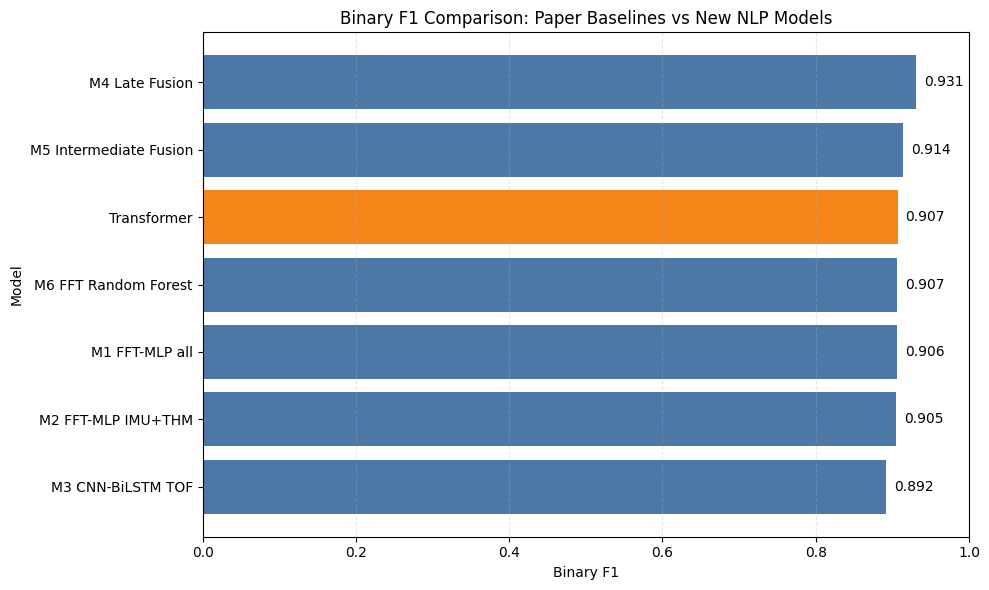

In [11]:
plot_df = comparison_df.dropna(subset=["binary_f1"]).copy()
plot_df = plot_df.sort_values("binary_f1", ascending=True)

colors = plot_df["source"].map({
    "Paper baseline": "#4C78A8",
    "New NLP model": "#F58518",
}).fillna("#999999")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["model"], plot_df["binary_f1"], color=colors)
plt.xlabel("Binary F1")
plt.ylabel("Model")
plt.title("Binary F1 Comparison: Paper Baselines vs New NLP Models")
plt.xlim(0, 1)
plt.grid(axis="x", linestyle="--", alpha=0.3)

for i, value in enumerate(plot_df["binary_f1"]):
    plt.text(value + 0.01, i, f"{value:.3f}", va="center")

plt.tight_layout()
plt.show()

Finally, we export the merged comparison table so it can be reused in the report, presentation, or later notebooks without recomputing the merge.

In [12]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

comparison_csv = RESULTS_DIR / "evaluation_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)

print(f"Saved combined comparison table to: {comparison_csv}")

print("\nNotes:")
print("- `binary_f1` is the main cross-family metric that all models share.")
print("- `macro18`, `macro_kplus1`, and `acc` apply only to the paper sensor baselines.")
print("- `macro_binary` applies only to the NLP binary classifiers.")

Saved combined comparison table to: c:\Users\Son\Documents\GitHub\2026-winter-capstone-project-group4_wecandothis\results\evaluation_comparison.csv

Notes:
- `binary_f1` is the main cross-family metric that all models share.
- `macro18`, `macro_kplus1`, and `acc` apply only to the paper sensor baselines.
- `macro_binary` applies only to the NLP binary classifiers.
